In [ ]:
import pyomo.environ as pyo

c,h,b = 5, 2, 10
demands = {1: 10, 2: 20, 3: 30}      
probabilities = {1: 0.3, 2: 0.4, 3: 0.3} 


model = pyo.ConcreteModel(name="Linearized_Newsvendor")
model.K = pyo.Set(initialize=demands.keys())
model.x = pyo.Var(within=pyo.NonNegativeReals)
model.t = pyo.Var(model.K, within=pyo.Reals)



def objective_rule(model):
    return sum(probabilities[k] * model.t[k] for k in model.K)
model.Objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)


def shortage_rule(model, k):
    return (c - b) * model.x - model.t[k] <= -b * demands[k]
model.Shortage_Constraint = pyo.Constraint(model.K, rule=shortage_rule)


def excess_rule(model, k):
    return (c + h) * model.x - model.t[k] <= h * demands[k]
model.Excess_Constraint = pyo.Constraint(model.K, rule=excess_rule)


solver = pyo.SolverFactory('appsi_highs')
results = solver.solve(model)

print("Estado de la optimización:", results.solver.termination_condition)
print(f"Cantidad Óptima a Ordenar (x): {pyo.value(model.x)} unidades")
print(" " * 40)
for k in model.K:
    print(f"Escenario {k} (Demanda {demands[k]}): Costo Calculado (t_{k}) = ${pyo.value(model.t[k])}")
print(" " * 40)
print(f"Costo Total Esperado Minimizado: ${pyo.value(model.Objective)}")

Estado de la optimización: optimal
Cantidad Óptima a Ordenar (x): 20.0 unidades
                                        
Escenario 1 (Demanda 10): Costo Calculado (t_1) = $120.0
Escenario 2 (Demanda 20): Costo Calculado (t_2) = $100.0
Escenario 3 (Demanda 30): Costo Calculado (t_3) = $200.0
                                        
Costo Total Esperado Minimizado: $136.0


Óptimo Monte Carlo: x = 32.32, costo = 67.70


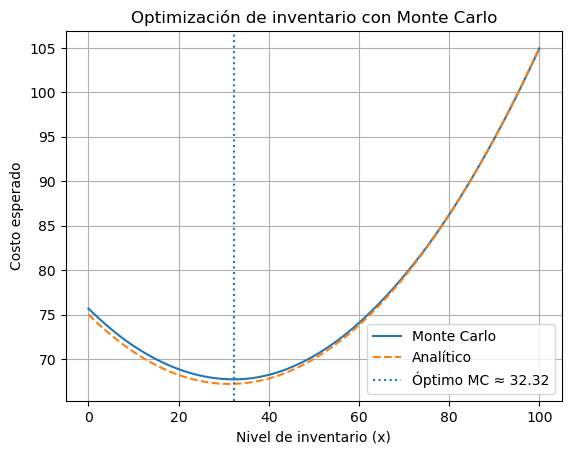

In [7]:
import numpy as np
import matplotlib.pyplot as plt


c = 1
b = 1.5
h = 0.1
N = 10000  

def G(x, d):
    return c*x + b*np.maximum(d - x, 0) + h*np.maximum(x - d, 0)


D = np.random.uniform(0, 100, N)
x_values = np.linspace(0, 100, 100)
costos_mc = []

for x in x_values:
    costos = G(x, D)
    costo_esperado = np.mean(costos)
    costos_mc.append(costo_esperado)

costos_mc = np.array(costos_mc)

costos_analiticos = 75 - 0.5*x_values + 0.008*(x_values**2)

x_opt_mc = x_values[np.argmin(costos_mc)]
costo_min_mc = np.min(costos_mc)

print(f"Óptimo Monte Carlo: x = {x_opt_mc:.2f}, costo = {costo_min_mc:.2f}")
plt.figure()
plt.plot(x_values, costos_mc, label="Monte Carlo")
plt.plot(x_values, costos_analiticos, '--', label="Analítico")
plt.axvline(x_opt_mc, linestyle=':', label=f'Óptimo MC ≈ {x_opt_mc:.2f}')
plt.xlabel("Nivel de inventario (x)")
plt.ylabel("Costo esperado")
plt.title("Optimización de inventario con Monte Carlo")
plt.legend()
plt.grid()
plt.show()